In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

# 1. Check if the file is in the local directory
if os.path.exists('train.csv'):
    print("Loading local train.csv...")
    df = pd.read_csv('train.csv')

# 2. If not local, try Colab Secrets
else:
    print("Local file not found. Mounting Google Drive securely...")
    from google.colab import drive, userdata
    drive.mount('/content/gdrive')

    private_path = userdata.get('CSV_PATH')
    df = pd.read_csv(private_path)

print("Dataset Shape:", df.shape)

Local file not found. Mounting Google Drive securely...
Mounted at /content/gdrive
Dataset Shape: (970, 11)


In [3]:
# List of metadata and target columns to check for cardinality
categorical_columns = [
    'issue_area', 'issue_category', 'issue_sub_category',
    'issue_category_sub_category', 'customer_sentiment',
    'product_category', 'product_sub_category',
    'issue_complexity', 'agent_experience_level',
    'agent_experience_level_desc'
]

print("Cardinality (Number of Unique Values) per Feature:\n" + "-"*50)
for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"{col.ljust(30)}: {unique_count}")

Cardinality (Number of Unique Values) per Feature:
--------------------------------------------------
issue_area                    : 6
issue_category                : 40
issue_sub_category            : 109
issue_category_sub_category   : 109
customer_sentiment            : 3
product_category              : 3
product_sub_category          : 50
issue_complexity              : 3
agent_experience_level        : 3
agent_experience_level_desc   : 3


Dataset Shape: (970, 11)

Missing Values:
 issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64


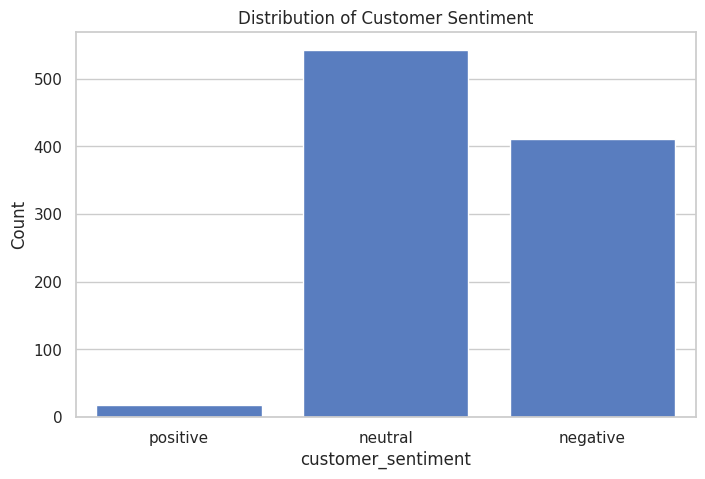

Agent Experience Levels in the Dataset:
agent_experience_level
junior           490
experienced      339
inexperienced    141
Name: count, dtype: int64


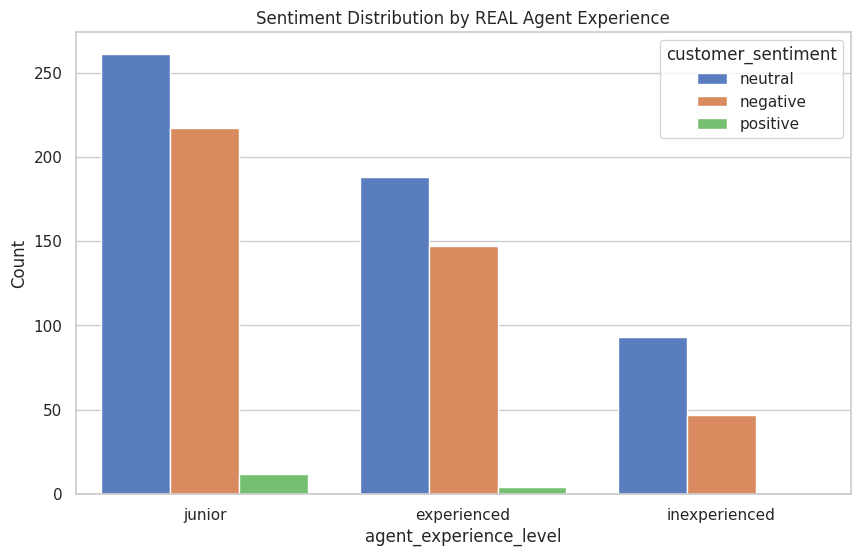

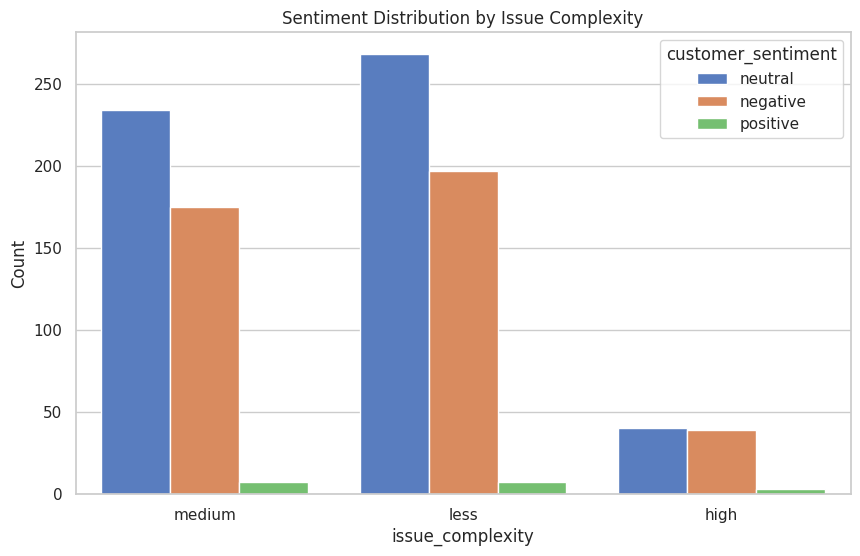

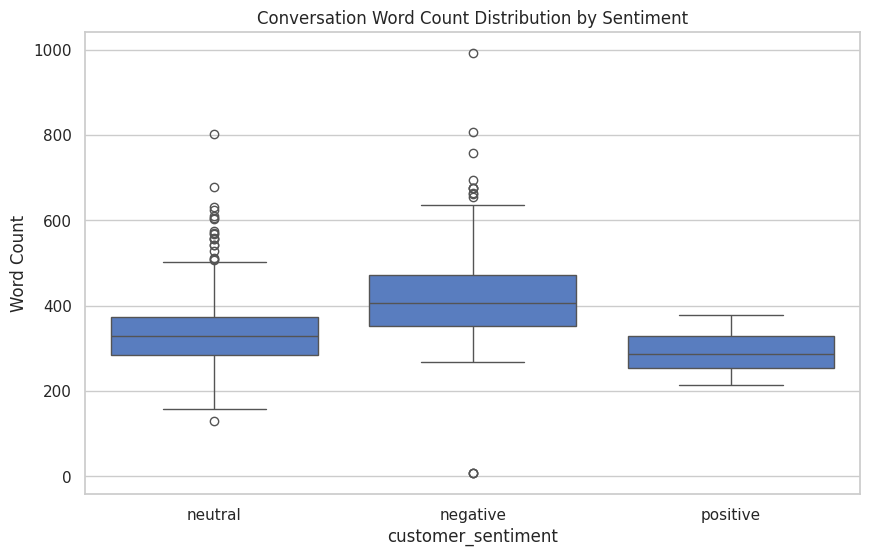


Conversations exceeding 350 words: 517 out of 970
Percentage: 53.30%


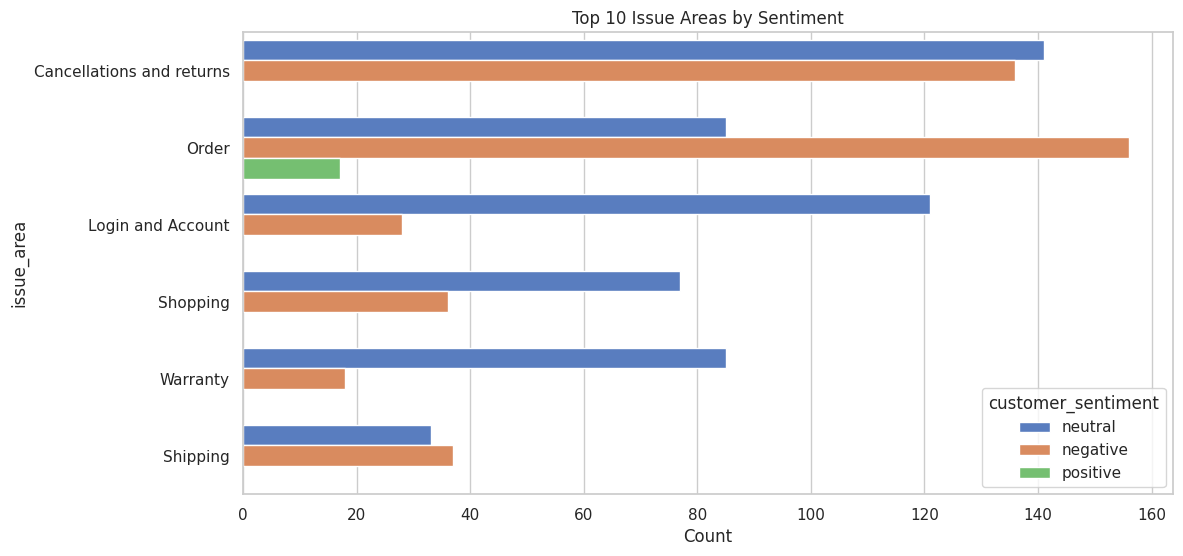

In [4]:
# Set visual style for the report
sns.set_theme(style="whitegrid", palette="muted")


print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# 2. Target Variable Distribution (Does neutral dominate?)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='customer_sentiment', order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Customer Sentiment')
plt.ylabel('Count')
plt.show()


# 3.1. Check all unique agent experience levels and their exact counts
experience_counts = df['agent_experience_level'].value_counts(dropna=False)

print("Agent Experience Levels in the Dataset:")
print(experience_counts)

# 3.2. Dynamically grab the real categories
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='agent_experience_level',
    hue='customer_sentiment',
    order=experience_counts.index # This dynamically uses the actual categories
)
plt.title('Sentiment Distribution by REAL Agent Experience')
plt.ylabel('Count')
plt.show()

# 4. Metadata Correlations: Sentiment vs. Issue Complexity
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='issue_complexity', hue='customer_sentiment')
plt.title('Sentiment Distribution by Issue Complexity')
plt.ylabel('Count')
plt.show()

# 5. Text Statistics (The Token Limit Check)
# Calculate a rough word count to estimate token length.
# 1 word is roughly 1.3 to 1.5 tokens for Byte-Pair Encoding.
df['word_count'] = df['conversation'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='customer_sentiment', y='word_count')
plt.title('Conversation Word Count Distribution by Sentiment')
plt.ylabel('Word Count')
plt.show()


# Check how many rows exceed a safe word count (e.g., 350 words ~ 500 tokens)
oversized_convos = df[df['word_count'] > 350]
print(f"\nConversations exceeding 350 words: {len(oversized_convos)} out of {len(df)}")
print(f"Percentage: {(len(oversized_convos) / len(df)) * 100:.2f}%")

# 6. High-Level Overview of Issue Areas
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='issue_area', hue='customer_sentiment',
              order=df['issue_area'].value_counts().index[:10]) # Top 10 areas
plt.title('Top 10 Issue Areas by Sentiment')
plt.xlabel('Count')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# 1. Map sentiments to integers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['customer_sentiment'].map(label_mapping)

# 2. Stratified Split (80/20)
# Stratify ensures both sets get the same ratio of the rare 'positive' class
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Training set size: 776
Validation set size: 194


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer


class CustomerSupportDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=512, head_len=128):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.head_len = head_len
        # The remaining tokens will be taken from the tail
        # Subtract 2 to leave room for the <s> and </s> special tokens
        self.tail_len = max_len - head_len - 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]

        # 1. Text Prepending
        context = (
            f"Area: {row['issue_area']} | "
            f"Complexity: {row['issue_complexity']} | "
            f"Product: {row['product_category']} | "
            f"Agent: {row['agent_experience_level']} | "
            f"Conversation: {row['conversation']}"
        )

        # 2. Tokenize directly to IDs, explicitly telling HF NOT to warn us
        token_ids = self.tokenizer(
            context,
            add_special_tokens=False,
            truncation=False
        )['input_ids']

        # 3. Apply Head + Tail Truncation if too long
        if len(token_ids) > (self.max_len - 2):
            head_ids = token_ids[:self.head_len]
            tail_ids = token_ids[-self.tail_len:]
            token_ids = head_ids + tail_ids

        # 4. Add special tokens (<s> and </s> for RoBERTa)
        input_ids = [self.tokenizer.cls_token_id] + token_ids + [self.tokenizer.sep_token_id]

        # 5. Create Attention Mask (1 for real tokens, 0 for padding)
        attention_mask = [1] * len(input_ids)

        # 6. Pad up to max_len
        padding_length = self.max_len - len(input_ids)
        input_ids = input_ids + ([self.tokenizer.pad_token_id] * padding_length)
        attention_mask = attention_mask + ([0] * padding_length)

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(row['label'], dtype=torch.long)
        }

# Initialize Tokenizer and DataLoaders

# Set model_max_length to a huge number to silence token length for model exceeded warnings
# Custom Dataset class will enforce the real 512 limit.
tokenizer = RobertaTokenizer.from_pretrained('roberta-base', model_max_length=8192)

train_dataset = CustomerSupportDataset(train_df, tokenizer)
val_dataset = CustomerSupportDataset(val_df, tokenizer)

# Using a batch size of 8 to be safe on memory
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("DataLoaders successfully created!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DataLoaders successfully created!


In [7]:
# Grab one single batch from the training loader
batch = next(iter(train_loader))

# Extract the first item in this batch
sample_input_ids = batch['input_ids'][0]
sample_attention_mask = batch['attention_mask'][0]
sample_label = batch['labels'][0]

print(f"Tensor Shape: {sample_input_ids.shape}") # Should be [512]
print(f"Label ID: {sample_label.item()}")

print("\n--- WHAT THE MODEL ACTUALLY SEES ---")
# tokenizer.decode() translates the integer tensor back to English
# It will also reveal the <s> (start), </s> (end), and <pad> tokens!
decoded_text = tokenizer.decode(sample_input_ids)
print(decoded_text)

Tensor Shape: torch.Size([512])
Label ID: 1

--- WHAT THE MODEL ACTUALLY SEES ---
<s>Area: Login and Account | Complexity: less | Product: Electronics | Agent: junior | Conversation: Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?

Customer: Hi, Sarah. I need to change my email address for my account, and I'm not sure how to do it.

Agent: I can help you with that. Can you please provide me with your account information, such as your full name and account number?

Customer: Yes, my name is John Doe, and my account number is BB123456789.

Agent: Thank you, John. Let me check your account. Can you please confirm your current email address on file?

Customer: Yes, it's johndoe@email.com.

Agent: Great. To change your email address, you need to log in to your account and go to the account settings. From there, you can update your email address.

Customer: I don't have access to my old email address anymore, so I can't log in.

Agent: I 

In [8]:
import torch.nn as nn
from transformers import RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


# 1. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Load the pre-trained model
# Specify 3 labels (Negative, Neutral, Positive) per the assignment requirements
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=3
)
model.to(device)

# 3. Calculate Class Weights
# This computes the inverse frequency of the classes in training set
# This is incredibly helpful, the dataset has drastic class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Convert to a PyTorch tensor and move to the GPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Calculated Class Weights: {weights_tensor}")

# 4. Define Loss Function and Optimizer
# Passing the weights forces PyTorch to penalize minority class errors heavily
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Standard optimizer for Transformers.
# Use a very small learning rate (2e-5) because the dataset is tiny and will overfit quickly.
optimizer = AdamW(model.parameters(), lr=2e-5)

Using device: cuda


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Calculated Class Weights: tensor([ 0.7862,  0.5960, 19.8974], device='cuda:0')


In [9]:
!pip install wandb
import wandb

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: osmnsmh42 (osmnsmh42-novit-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
import torch
import numpy as np
from sklearn.metrics import f1_score

EPOCHS = 10

# 1. Initialize the WANDB run
wandb.init(
    project="customer-sentiment-analysis",
    name="roberta-base-10-epochs",
    config={
        "learning_rate": 2e-5,
        "architecture": "roberta-base",
        "dataset": "custom_prepended",
        "epochs": EPOCHS,
        "batch_size": 8
    }
)

for epoch in range(EPOCHS):
    # ==========================================
    #               TRAINING PHASE
    # ==========================================
    model.train()
    total_train_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} | Train Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)

    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval()
    total_val_loss = 0
    all_preds = []
    all_true_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            true_labels = labels.cpu().numpy()

            all_preds.extend(preds)
            all_true_labels.extend(true_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    val_f1_macro = f1_score(all_true_labels, all_preds, average='macro')

    print("-" * 60)
    print(f"Epoch {epoch+1} Summary:")
    print(f"Average Training Loss: {avg_train_loss:.4f}")
    print(f"Average Validation Loss: {avg_val_loss:.4f}")
    print(f"Validation F1-Macro:   {val_f1_macro:.4f}")
    print("-" * 60)

    # 2. Log metrics to WANDB at the end of every epoch
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_f1_macro": val_f1_macro
    })

# 3. Close the WANDB run cleanly
wandb.finish()
print("Training Complete and logged to WANDB!")

Epoch 1 | Train Batch 0/97 | Loss: 1.1230
Epoch 1 | Train Batch 20/97 | Loss: 0.7850
Epoch 1 | Train Batch 40/97 | Loss: 1.7826
Epoch 1 | Train Batch 60/97 | Loss: 0.7203
Epoch 1 | Train Batch 80/97 | Loss: 0.4864
------------------------------------------------------------
Epoch 1 Summary:
Average Training Loss: 0.9638
Average Validation Loss: 0.7042
Validation F1-Macro:   0.4810
------------------------------------------------------------
Epoch 2 | Train Batch 0/97 | Loss: 0.5943
Epoch 2 | Train Batch 20/97 | Loss: 0.6165
Epoch 2 | Train Batch 40/97 | Loss: 0.1563
Epoch 2 | Train Batch 60/97 | Loss: 0.5814
Epoch 2 | Train Batch 80/97 | Loss: 0.4940
------------------------------------------------------------
Epoch 2 Summary:
Average Training Loss: 0.5999
Average Validation Loss: 0.4682
Validation F1-Macro:   0.5891
------------------------------------------------------------
Epoch 3 | Train Batch 0/97 | Loss: 0.1628
Epoch 3 | Train Batch 20/97 | Loss: 0.3359
Epoch 3 | Train Batch 40/

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▅▃▃▂▂▁▁▁▁
val_f1_macro,▁▃▃▆▆▆█▇█▆
val_loss,█▄▄▃▄▁▅▅▂▄
epoch,10
train_loss,0.05296
val_f1_macro,0.75706
val_loss,0.46964


Training Complete and logged to WANDB!
